In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
!pwd

/content


In [ ]:
!mkdir example_data

In [ ]:
# Set matplotlib backend
%matplotlib inline
#%matplotlib notebook
#%matplotlib qt

In [ ]:
from datasets import load_dataset, Audio

dataset = load_dataset("PolyAI/minds14", "en-US", split="train")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

en-US/train-00000-of-00001.parquet:   0%|          | 0.00/34.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/563 [00:00<?, ? examples/s]

In [ ]:
import pandas as pd
df = pd.DataFrame(dataset)
df.head()

,path,audio,transcription,english_transcription,intent_class,lang_id
0,en-US~JOINT_ACCOUNT/602ba55abb1e6d0fbce92065.wav,<datasets.features._torchcodec.AudioDecoder ob...,I would like to set up a joint account with my...,I would like to set up a joint account with my...,11,4
1,en-US~JOINT_ACCOUNT/602baf24bb1e6d0fbce922a7.wav,<datasets.features._torchcodec.AudioDecoder ob...,Henry County set up a joint account with my wi...,Henry County set up a joint account with my wi...,11,4
2,en-US~JOINT_ACCOUNT/602b9f97963e11ccd901cc32.wav,<datasets.features._torchcodec.AudioDecoder ob...,hi I'd like to set up a joint account with my ...,hi I'd like to set up a joint account with my ...,11,4
3,en-US~JOINT_ACCOUNT/602bacab5f67b421554f6488.wav,<datasets.features._torchcodec.AudioDecoder ob...,how do I start a joint account,how do I start a joint account,11,4
4,en-US~JOINT_ACCOUNT/602b9d4cbb1e6d0fbce91fa4.wav,<datasets.features._torchcodec.AudioDecoder ob...,can you help me set up a joint bank account,can you help me set up a joint bank account,11,4


In [ ]:
# (i) Specify the directory path and file name

# Create a string variable with the name of the file you'd like to load (here: 'example_cells_1.tif').
# Suggested name for the variable: filename
# Note: Paths and filenames can contain slashes, empty spaces and other special symbols, which can cause
#       trouble for programming languages under certain circumstances. To circumvent such trouble, add
#       the letter r before your string definition to create a so-called 'raw string', which is not
#       affected by these problems (e.g. `my_raw_string = r"some string with funny symbols: \\\!/~***!"`).
filename = r'example_cells_1.tif'

# If the file is not in the current working directory, you must also have a way of specifying the path
# to the directory where the file is stored. Most likely, your example images are stored in a directory
# called 'example_data' in the same folder as this notebook. Note that you can use either the full path
#  - something like r"/home/jack/data/python_image_analysis/example_data"
# or the relative path, starting from the current working directory
#   - here that would just be r"example_data"
# Create a string variable with the path to the directory that contains the file you'd like to load.
# Suggested name for the variable: dirpath
dirpath = r'example_data'  # Relative path
#dirpath = r'/home/jack/data/python_image_analysis/example_data/example_cells_1.tif'  # Absolute path

In [ ]:
# (ii) Combine the directory path and file name into one variable, the file path

# Import the function 'join' from the module 'os.path'
# This function automatically takes care of the slashes that need to be added when combining two paths.
from os.path import join

# Use the 'join' function to combine the directory path with the file name and create a new variable.
# Print the result to see that everything is correct (this is always a good idea!)
# Suggested name for the variable: filepath
filepath = join(dirpath, filename)
print(filepath)

example_data/example_cells_1.tif


In [ ]:
img = cv2.imread("/content/example_data/example_cells_1.tif")
if img is None:
    print("Error: Image not found")
else:
  print("image successfull")

image successfull


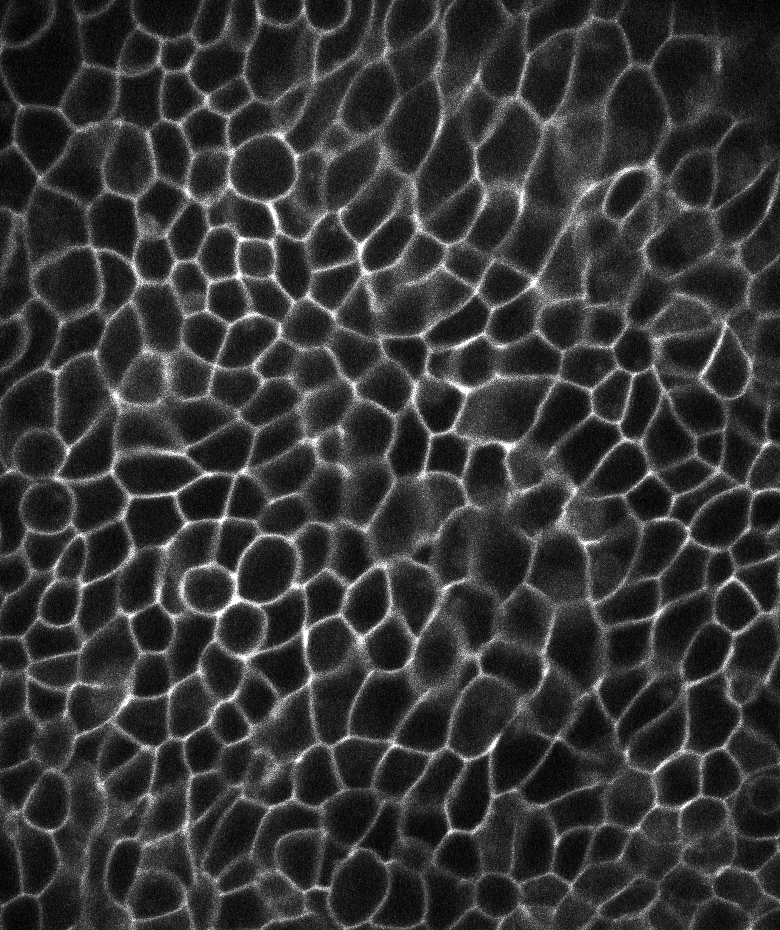

In [ ]:
from google.colab.patches import cv2_imshow
cv2_imshow(img)

In [ ]:
# (iv) Check that everything is in order

# Check that 'img' is a variable of type 'ndarray' - use Python's built-in function 'type'.
print("Loaded array is of type:", type(img))

# Print the shape of the array using the numpy-function 'shape'.
# Make sure you understand the output!
print("Loaded array has shape:", img.shape)

# Check the datatype of the individual numbers in the array. You can use the array attribute 'dtype' to do so.
# Make sure you understand the output!
print("Loaded values are of type:", img.dtype)

# SOLUTION NOTE: The dtype should be 'uint8', because these are unsigned 8-bit integer images.
#                This means that the intensity values range from 0 to 255 in steps of 1.

Loaded array is of type: <class 'numpy.ndarray'>
Loaded array has shape: (930, 780, 3)
Loaded values are of type: uint8


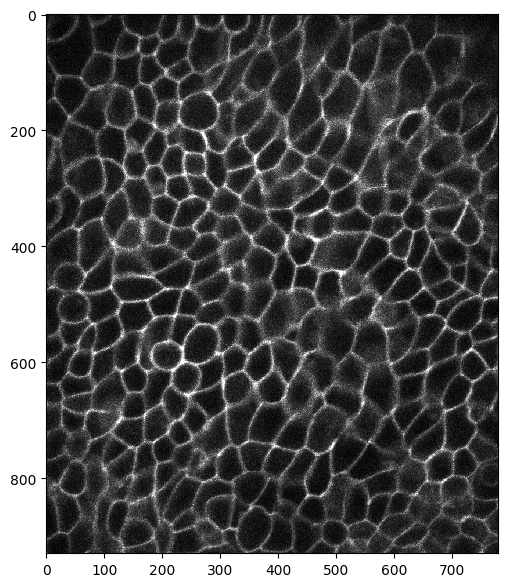

In [ ]:
# (v) Look at the image to confirm that everything worked as intended

# To plot the array as an image, use pyplot's functions 'plt.imshow' followed by 'plt.show'.
# Check the documentation for 'plt.imshow' and note the parameters that can be specified, such as colormap (cmap)
# and interpolation. Since you are working with scientific data, interpolation is unwelcome, so you should set it
# to "none". The most common cmap for grayscale images is naturally "gray".
# You may also want to adjust the size of the figure. You can do this by preparing the figure canvas with
# the function 'plt.figure' before calling 'plt.imshow'. The canvas size is adjusted using the keyword argument
# 'figsize' when calling 'plt.figure'.
plt.figure(figsize=(7,7))
plt.imshow(img, interpolation='none', cmap='gray')
plt.show()

In [ ]:
sigma = 3

In [ ]:
img_smooth = cv2.GaussianBlur(img, (0,0), sigma)

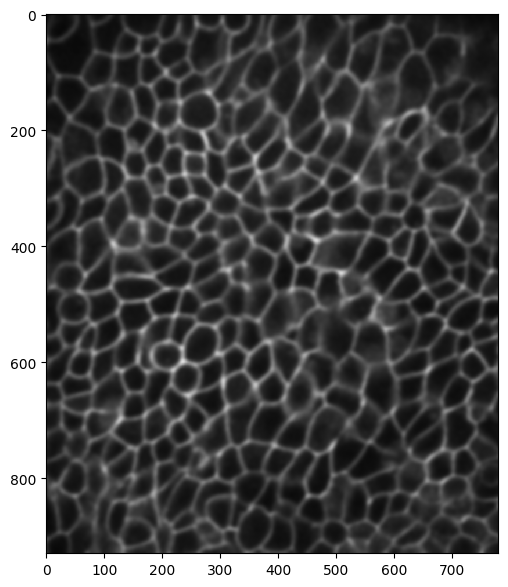

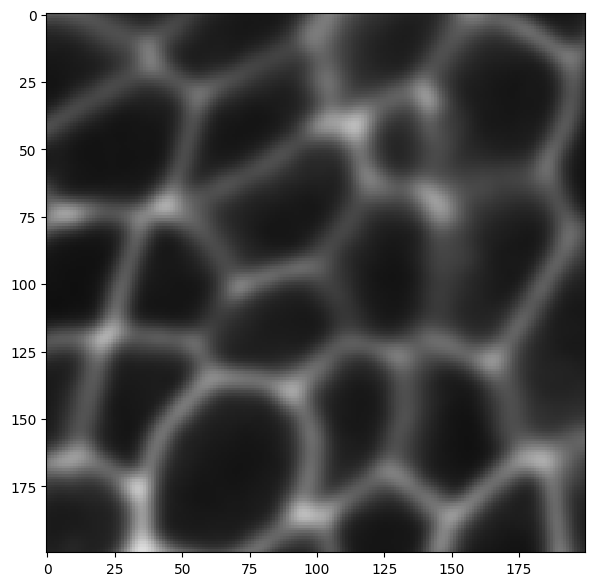

In [ ]:
plt.figure(figsize=(7,7))
plt.imshow(img_smooth, interpolation='none', cmap='gray')
plt.show()

plt.figure(figsize=(7,7))
plt.imshow(img_smooth[400:600, 200:400], interpolation='none', cmap='gray')
plt.show()

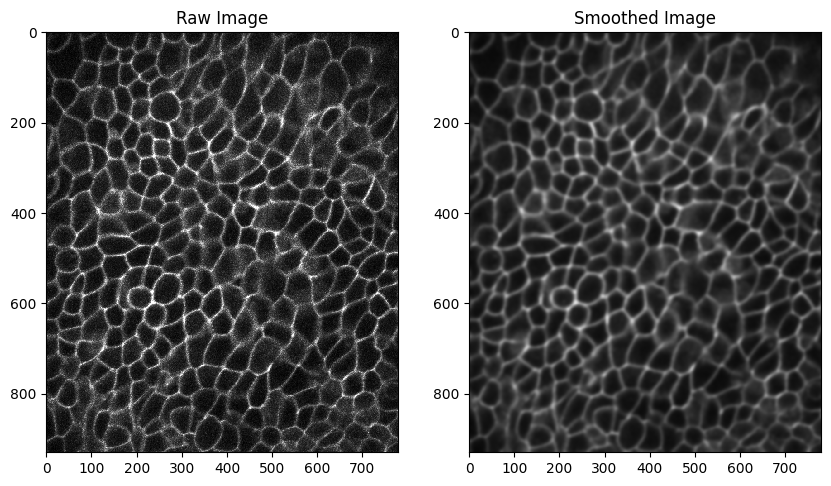

In [ ]:
# (iv) BONUS: Show the raw and smoothed images side by side using 'plt.subplots'

fig, ax = plt.subplots(1, 2, figsize=(10,7))
ax[0].imshow(img, interpolation='none', cmap='gray')
ax[1].imshow(img_smooth, interpolation='none', cmap='gray')
ax[0].set_title('Raw Image')
ax[1].set_title('Smoothed Image')
plt.show()

In [ ]:
# (i) Create a variable for a manually set threshold, which should be an integer

# This can be changed later to find a suitable value.
thresh = 70

In [ ]:
# (ii) Perform thresholding on the smoothed image

# Remember that you can use relational (Boolean) expressions such as 'smaller' (<), 'equal' (==)
# or 'greater or equal' (>=) with numpy arrays - and you can directly assign the result to a new
# variable.
mem = img_smooth > thresh

# Check the dtype of your thresholded image
# You should see that the dtype is 'bool', which stands for 'Boolean' and means the array
# is now simply filled with 'True' and 'False', where 'True' is the foreground (the regions
# above the threshold) and 'False' is the background.
print(mem.dtype)

bool


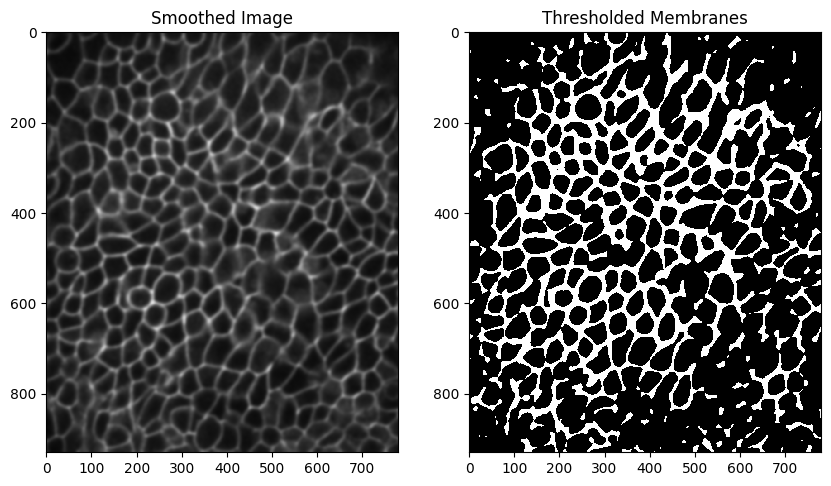

In [ ]:
# (iii) Visualize the result

import numpy as np

fig, ax = plt.subplots(1, 2, figsize=(10,7))
ax[0].imshow(img_smooth, interpolation='none', cmap='gray')
ax[1].imshow(mem.astype(np.uint8) * 255, interpolation='none', cmap='gray')
ax[0].set_title('Smoothed Image')
ax[1].set_title('Thresholded Membranes')
plt.show()

In [ ]:
# (iv) Try out different thresholds to find the best one

# If you are using jupyter notebook, you can adapt the code below to
# interactively change the threshold and look for the best one. These
# kinds of interactive functions are called 'widgets' and are very
# useful in exploratory data analysis to create greatly simplified
# 'User Interfaces' (UIs) on the fly.
# As a bonus exercise, try to understand or look up how the widget works
# and play around with it a bit!

# Prepare widget
from ipywidgets import interact


@interact(thresh=(10,250,10))
def select_threshold(thresh=100):

    # Thresholding
    mem = img_smooth > thresh

    # Visualization
    plt.figure(figsize=(7,7))
    plt.imshow(mem.astype(np.uint8) * 255, interpolation='none', cmap='gray')
    plt.show()

interactive(children=(IntSlider(value=100, description='thresh', max=250, min=10, step=10), Output()), _dom_cl…

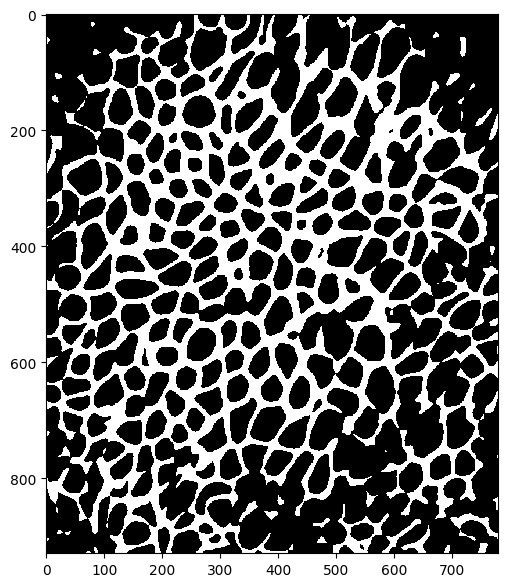

In [ ]:
# (v) Perfom automated threshold detection with Otsu's method

# The scikit-image module 'skimage.filters.thresholding' provides
# several threshold detection algorithms. The most popular one
# among them is Otsu's method. Using what you've learned so far,
# import the 'threshold_otsu' function, use it to automatically
# determine a threshold for the smoothed image, apply the threshold,
# and visualize the result.

# Import
from skimage.filters.thresholding import threshold_otsu

# Convert the smoothed image to grayscale for Otsu's method
# Taking the mean across the color channels is a common way to do this.
img_smooth_gray = cv2.cvtColor(img_smooth, cv2.COLOR_BGR2GRAY)

# Calculate and apply threshold
thresh = threshold_otsu(img_smooth_gray)
mem = img_smooth_gray > thresh

# Visualization
plt.figure(figsize=(7,7))
plt.imshow(mem.astype(np.uint8) * 255, interpolation='none', cmap='gray')
plt.show()

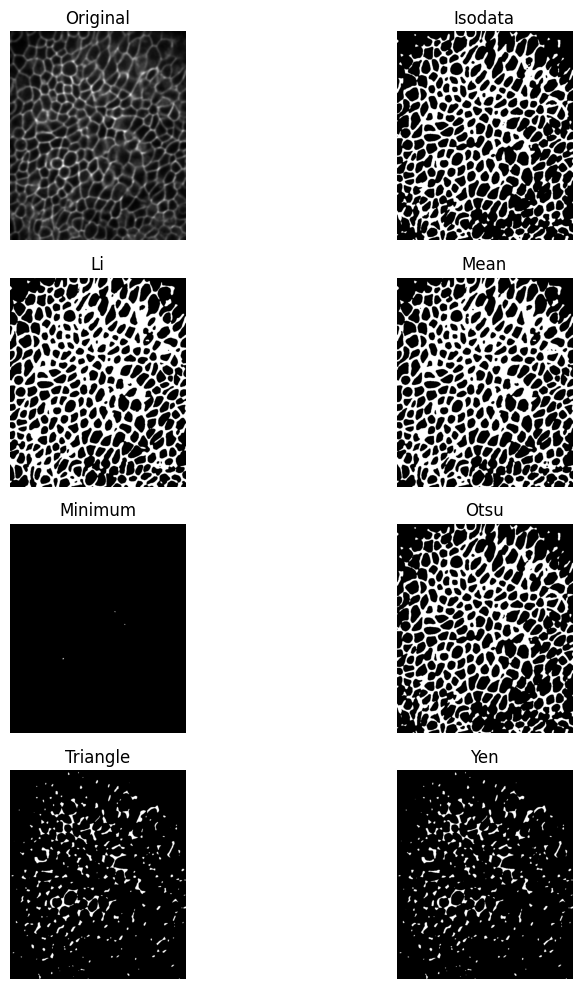

In [ ]:
# (vi) BONUS: Did you notice the 'try_all_threshold' function?

# That's convenient! Use it to automatically test the threshold detection
# functions in 'skimage.filters.thresholding'. Don't forget to adjust the
# 'figsize' parameter so the resulting images are clearly visible.
from skimage.filters.thresholding import try_all_threshold
fig = try_all_threshold(img_smooth_gray, figsize=(10,10), verbose=False)